# Code for Chapter 6 @ SSTC-NEU modified by Fu
## Convolutional Neural Networks

In [25]:
import torch # torch will allow us to create tensors.
import torch.nn as nn # torch.nn allows us to create a neural network.
import torch.nn.functional as F # nn.functional give us access to the activation and loss functions.
from torch.optim import Adam # optim contains many optimizers. This time we're using Adam

import lightning as L # lightning has tons of cool tools that make neural networks easier
from torch.utils.data import TensorDataset, DataLoader # these are needed for the training data

import matplotlib.pyplot as plt ## matplotlib allows us to draw the images used for input.

## NOTE: If you get an error running this block of code, it is probably
##       because you installed a new package earlier and forgot to
##       restart your session for python to find the new module(s).
##
##       To restart your session:
##       - In Google Colab, click on the "Runtime" menu and select
##         "Restart Session" from the pulldown menu
##       - In a local jupyter notebook, click on the "Kernel" menu and select
##         "Restart Kernel" from the pulldown menu

In [26]:
## Create a 6x6 matrix of numbers where 0 represents white
## and 1 represents black.
o_image = [[0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1],
           [1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0]]
o_image # print out the matrix to verify that it is what we expect

[[0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 1, 0],
 [1, 0, 0, 0, 0, 1],
 [1, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0]]

In [27]:
x_image = [[1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1]]
x_image

[[1, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0],
 [0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 1, 0],
 [1, 0, 0, 0, 0, 1]]

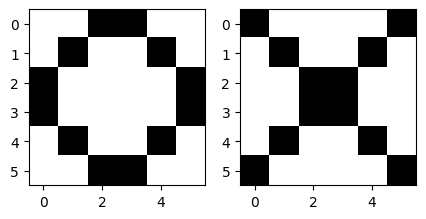

In [28]:
## To draw the o_image and x_image, we first call subplots(), which creates 
## an array, called axarr[], with an entry for each element in a grid
## specified by nrows and ncols.
fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))

## Now we pass o_image and x_image to .imshow() for each element
## in the grid created by plt.subplots()
axarr[0].imshow(o_image, cmap='gray_r') ## Setting cmap='gray_r' gives us reverse grayscale.
axarr[1].imshow(x_image, cmap='gray_r')

In [29]:
## Convert the images into tensors...
input_images = torch.tensor([o_image, x_image]).type(torch.float32)

In [30]:
## Create the labels for the input images
input_labels = torch.tensor([[1.0, 0.0], [0.0, 1.0]]).type(torch.float32)

In [31]:
## Now combine input_images and input_labels into a TensorDataset...
dataset = TensorDataset(input_images, input_labels) 
## ...and use the TensorDataset to create a DataLoader.
dataloader = DataLoader(dataset)

In [32]:
for batch_num, (images, labels) in enumerate(dataloader): 
    print("batch_num:", batch_num)
    print(images)
    print(labels)
    print() ## print a blank line to separate each batch

batch_num: 0
tensor([[[0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.]]])
tensor([[1., 0.]])

batch_num: 1
tensor([[[1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.]]])
tensor([[0., 1.]])



In [33]:
## Now build a simple CNN...
class SimpleCNN(L.LightningModule):
    
    def __init__(self):
        
        super().__init__() ## We call the __init__() for the parent, LightningModule, so that it
                           ## can initialize itself as well.
        
        ## Now we set the seed for the random number generorator.
        ## This ensures that when you create a model from this class, that model
        ## will start off with the exact same random numbers that I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=21)
        
        ############################################################################
        ##
        ## Here is where we initialize the Weights and Biases for the CNN
        ##
        ############################################################################
        
        ## The filter is created and applied by nn.Conv2d().
        ## in_channels - The number of color channels that
        ##    the image has. Our black and white image only 
        ##    has one channel. However, color pictures usually have 3.
        ## out_channels - If we had multiple input channels, we could merge
        ##    them down to one output. Or we can increase the number of
        ##    output channels if we want.
        ## kernel_size - The size of the filter (aka kernel). In this case
        ##    we want a 3x3 filter, but you can select all kinds of sizes,
        ##    including sizes that are more rectangular than square.
        self.conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3)
        
        ## nn.MaxPool2d() does the max pooling step.
        ## kernel_size - The size of the filter (aka kernel) that does the
        ##    max pooling. We're using a 2x2 grid for our filter.
        ## stride - How much to move the filter each step. In this case
        ##    we're moving it 2 units. Thus, our 2x2 filter does max pooling
        ##    before moving 2 units over (or down). This means that our 
        ##    max pooling filter never overlaps itself.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        ## Lastly, we create the "normal" neural network that has
        ## 4 inputs, in_features=4, going to a single activation function, out_features=1, 
        ## in a single hidden layer...
        self.input_to_hidden = nn.Linear(in_features=4, out_features=1)
        ## ..and the single hidden layer, in_features=1, goes to
        ## two outputs, out_features=2
        self.hidden_to_output = nn.Linear(in_features=1, out_features=2)
        
        ## We'll use Cross Entropy to calculate the loss between what the 
        ## neural network's predictions and actual, or known, species for
        ## each row in the dataset.
        ## To learn more about Cross Entropy, see: https://youtu.be/6ArSys5qHAU
        ## NOTE: nn.CrossEntropyLoss applies a SoftMax function to the values
        ## we give it, so we don't have to do that oursevles. However,
        ## when we use this neural network (after it has been trained), we'll
        ## have to remember to apply a SoftMax function to the output.
        self.loss = nn.CrossEntropyLoss()

        
    def forward(self, x):
        
        ## First we apply a filter to the input image
        x = self.conv(x)
        
        ## Then we run the output from the filter through a ReLU...
        x = F.relu(x)
        
        ## Then we run the output from the ReLU through a Max Pooling layer...
        x = self.pool(x)
        
        ## Now, at this point we have a square matrix of values.
        ## So, in order to use those values as inputs to
        ## a neural network, we use torch.flatten() to 
        ## turn the matrix into a vector.
        x = torch.flatten(x, 1) # flatten all dimensions except batch 

        ## Now we run the flattened values through a neural network
        ## with a single hidden layer and a single ReLU activation
        ## function in that layer.
        x = self.input_to_hidden(x)
        x = F.relu(x)
        x = self.hidden_to_output(x)
        
        return x

    
    def configure_optimizers(self):
        ## In this example, configuring the optimizer
        ## consists of passing it the weights and biases we want
        ## to optimize, which are all in self.parameters(),
        ## and setting the learning rate with lr=0.001.
        return Adam(self.parameters(), lr=0.001)

    
    def training_step(self, batch, batch_idx):
        ## The first thing we do is split 'batch'
        ## into the input and label values.
        inputs, labels = batch 
        
        ## Then we run the input through the neural network
        outputs = self.forward(inputs)
        
        ## Then we calculate the loss.
        loss = self.loss(outputs, labels)
        
        ## Lastly, we could add the loss to a log file
        ## so that we can graph it later. This would
        ## help us decide if we have done enough training
        ## Ideally, if we do enough training, the loss
        ## should be small and not getting any smaller.
        # self.log("loss", loss) 
        
        return loss

In [34]:
model = SimpleCNN()

Seed set to 21


## 映射结果（Feature mapping）

CNN 把 **6×6 输入图** 逐步映射成更小的特征图，再拉成向量交给全连接分类：

| 阶段 | 形状 | 含义 |
|------|------|------|
| Input | 6×6 | 原始像素 |
| Conv | 4×4 | 3×3 卷积后的响应（可正可负） |
| ReLU | 4×4 | 截断负值后的特征 |
| MaxPool | 2×2 | 2×2 窗口取最大，降采样 |
| Flatten | 4 | 2×2 拉平，送入 `Linear(4→1→2)` |

下面用 `extract_feature_maps` 取出各层数组，用 `visualize_mapping_pipeline` 对比 **训练前 / 训练后** 的映射差异；用 `visualize_conv_kernels` 单独对比 **3×3 卷积核权重**。

In [35]:
def extract_feature_maps(model, images):
    """Full CNN mapping: input -> conv -> relu -> pool -> flatten (+ logits)."""
    feature_maps = []
    x = images.unsqueeze(1)  # (N, H, W) -> (N, 1, H, W)
    model.eval()
    with torch.no_grad():
        after_conv = model.conv(x)
        after_relu = F.relu(after_conv)
        after_pool = model.pool(after_relu)
        flat = torch.flatten(after_pool, 1)
        logits = model.hidden_to_output(F.relu(model.input_to_hidden(flat)))
    for i in range(x.shape[0]):
        feature_maps.append({
            'input': x[i, 0].numpy(),
            'after_conv': after_conv[i, 0].numpy(),
            'after_relu': after_relu[i, 0].numpy(),
            'after_pool': after_pool[i, 0].numpy(),
            'flatten': flat[i].numpy(),
            'logits': logits[i].numpy(),
        })
    model.train()
    return feature_maps


def print_mapping_summary(fmaps, title=''):
    """Print shapes and numeric mapping for O / X."""
    names = ['O', 'X']
    if title:
        print(f'=== {title} ===')
    for i, fm in enumerate(fmaps):
        print(f"\n[{names[i]}] Input {fm['input'].shape} -> Conv {fm['after_conv'].shape} -> "
              f"ReLU {fm['after_relu'].shape} -> Pool {fm['after_pool'].shape} -> "
              f"Flatten {fm['flatten'].shape}")
        print(f"  flatten = {fm['flatten'].round(4)}")
        print(f"  logits  = {fm['logits'].round(4)}  (softmax -> class probs)")


def visualize_mapping_pipeline(fmaps_before, fmaps_after):
    """
    每张图两行 (训练前/后)，五列: Input | Conv | ReLU | Pool | Flatten(柱状图)
    """
    n_images = len(fmaps_before)
    n_cols = 5
    fig, axes = plt.subplots(n_images * 2, n_cols, figsize=(14, 3.8 * n_images), squeeze=False)

    col_titles = ['Input\n6×6', 'Conv\n4×4', 'ReLU\n4×4', 'MaxPool\n2×2', 'Flatten\n(4-d)']
    row_labels = ['Before training', 'After training']
    image_names = ['O', 'X']

    for img_idx in range(n_images):
        for row_idx, (fmaps, row_label) in enumerate(zip([fmaps_before, fmaps_after], row_labels)):
            ax_row = img_idx * 2 + row_idx
            fm = fmaps[img_idx]
            heatmaps = [
                (fm['input'], 'gray_r'),
                (fm['after_conv'], 'RdBu_r'),
                (fm['after_relu'], 'viridis'),
                (fm['after_pool'], 'viridis'),
            ]
            for col_idx, (data, cmap) in enumerate(heatmaps):
                ax = axes[ax_row, col_idx]
                im = ax.imshow(data, cmap=cmap)
                ax.set_xticks([])
                ax.set_yticks([])
                if img_idx == 0 and row_idx == 0:
                    ax.set_title(col_titles[col_idx], fontsize=10)
                if col_idx == 0:
                    ax.set_ylabel(f'{image_names[img_idx]}\n{row_label}', fontsize=9)
            # Flatten bar chart
            ax_bar = axes[ax_row, 4]
            vals = fm['flatten']
            ax_bar.bar(range(len(vals)), vals, color='steelblue', edgecolor='black')
            ax_bar.axhline(0, color='gray', linewidth=0.8)
            ax_bar.set_xticks(range(len(vals)))
            ax_bar.set_xticklabels([f'c{i}' for i in range(len(vals))], fontsize=8)
            ax_bar.set_ylim(min(-0.5, vals.min() - 0.1), max(0.5, vals.max() + 0.1))

    fig.suptitle('CNN mapping pipeline (train weights change conv/pool → flatten → logits)', fontsize=12)
    plt.tight_layout()
    plt.show()


def snapshot_conv_kernel(model):
    """Save conv weight (3x3) and bias for before/after comparison.
    NOTE: must .copy() — .numpy() can share memory with conv.weight;
    training would overwrite 'before' snapshot otherwise (Delta all 0)."""
    w = model.conv.weight.detach().cpu().numpy()[0, 0].copy()
    b = float(model.conv.bias.detach().cpu().item())
    return {'weight': w, 'bias': b}


def print_conv_kernel_summary(kernel_before, kernel_after):
    print('=== Conv kernel (3x3) ===')
    print('Before training:')
    print(kernel_before['weight'].round(4))
    print(f"  bias = {kernel_before['bias']:.4f}")
    print('After training:')
    print(kernel_after['weight'].round(4))
    print(f"  bias = {kernel_after['bias']:.4f}")


def visualize_conv_kernels(kernel_before, kernel_after):
    """Side-by-side heatmaps of the learned 3x3 conv filter."""
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    panels = [
        (kernel_before['weight'], 'Before training\nweight'),
        (kernel_after['weight'], 'After training\nweight'),
        (kernel_after['weight'] - kernel_before['weight'], 'Delta\n(after - before)'),
    ]
    vmax = max(abs(panels[0][0]).max(), abs(panels[1][0]).max(), 1e-6)
    for ax, (data, title) in zip(axes, panels):
        im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(title, fontsize=10)
        for r in range(3):
            for c in range(3):
                ax.text(c, r, f'{data[r, c]:.2f}', ha='center', va='center', fontsize=8)
        ax.set_xticks([0, 1, 2])
        ax.set_yticks([0, 1, 2])
    fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    fig.suptitle(
        f"Conv2d kernel (3x3)  |  bias: {kernel_before['bias']:.3f} -> {kernel_after['bias']:.3f}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


# backward-compatible alias
def visualize_feature_maps(fmaps_before, fmaps_after, suptitle_prefix=''):
    visualize_mapping_pipeline(fmaps_before, fmaps_after)

In [36]:
## Mapping before training (random conv weights)
conv_kernel_before = snapshot_conv_kernel(model)
fmaps_before = extract_feature_maps(model, input_images)
print_mapping_summary(fmaps_before, title='Before training')
print('Initial conv kernel (3x3):')
print(conv_kernel_before['weight'].round(4), 'bias =', round(conv_kernel_before['bias'], 4))

=== Before training ===

[O] Input (6, 6) -> Conv (4, 4) -> ReLU (4, 4) -> Pool (2, 2) -> Flatten (4,)
  flatten = [0.0519 0.241  0.241  0.2137]
  logits  = [-1.2297  0.0999]  (softmax -> class probs)

[X] Input (6, 6) -> Conv (4, 4) -> ReLU (4, 4) -> Pool (2, 2) -> Flatten (4,)
  flatten = [0.241  0.0008 0.     0.241 ]
  logits  = [-1.3877  0.2595]  (softmax -> class probs)
Initial conv kernel (3x3):
[[-0.0176  0.0757 -0.3253]
 [-0.3069  0.0449 -0.1641]
 [ 0.0225  0.0729  0.1442]] bias = 0.0695


In [37]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(model, train_dataloaders=dataloader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name             | Type             | Params | Mode  | FLOPs
----------------------------------------------------------------------
0 | conv             | Conv2d           | 10     | train | 0    
1 | pool             | MaxPool2d        | 0      | train | 0    
2 | input_to_hidden  | Linear           | 5      | train | 0    
3 | hidden_to_output | Linear           | 4      | train | 0    
4 | loss             | CrossEntropyLoss | 0      | train | 0    
----------------------------

Epoch 4:   0%|          | 0/2 [00:00<?, ?it/s, v_num=26]         

Epoch 99: 100%|██████████| 2/2 [00:00<00:00, 170.33it/s, v_num=26]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 2/2 [00:00<00:00, 99.54it/s, v_num=26] 


=== Conv kernel (3x3) ===
Before training:
[[-0.0176  0.0757 -0.3253]
 [-0.3069  0.0449 -0.1641]
 [ 0.0225  0.0729  0.1442]]
  bias = 0.0695
After training:
[[ 0.1606  0.0757 -0.3451]
 [-0.3069  0.1898 -0.1967]
 [-0.0221  0.0404  0.2999]]
  bias = 0.1742


C:\user\default\AppData\Local\Temp\ipykernel_51372\1492137238.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


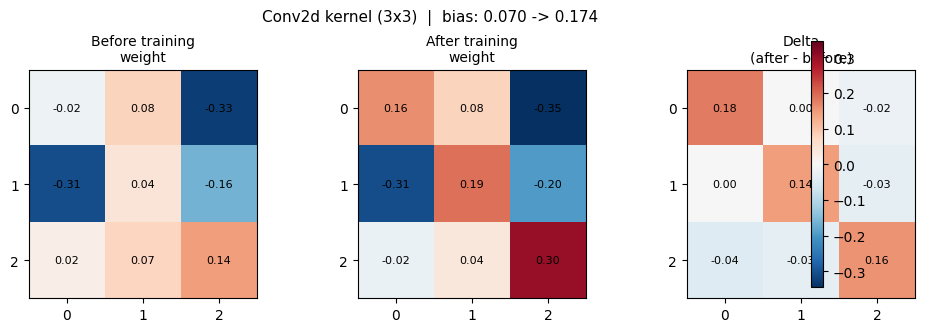

=== After training ===

[O] Input (6, 6) -> Conv (4, 4) -> ReLU (4, 4) -> Pool (2, 2) -> Flatten (4,)
  flatten = [0.3347 0.8244 0.8244 0.474 ]
  logits  = [-0.8298 -0.303 ]  (softmax -> class probs)

[X] Input (6, 6) -> Conv (4, 4) -> ReLU (4, 4) -> Pool (2, 2) -> Flatten (4,)
  flatten = [0.8244 0.     0.     0.8244]
  logits  = [-1.4551  0.3286]  (softmax -> class probs)


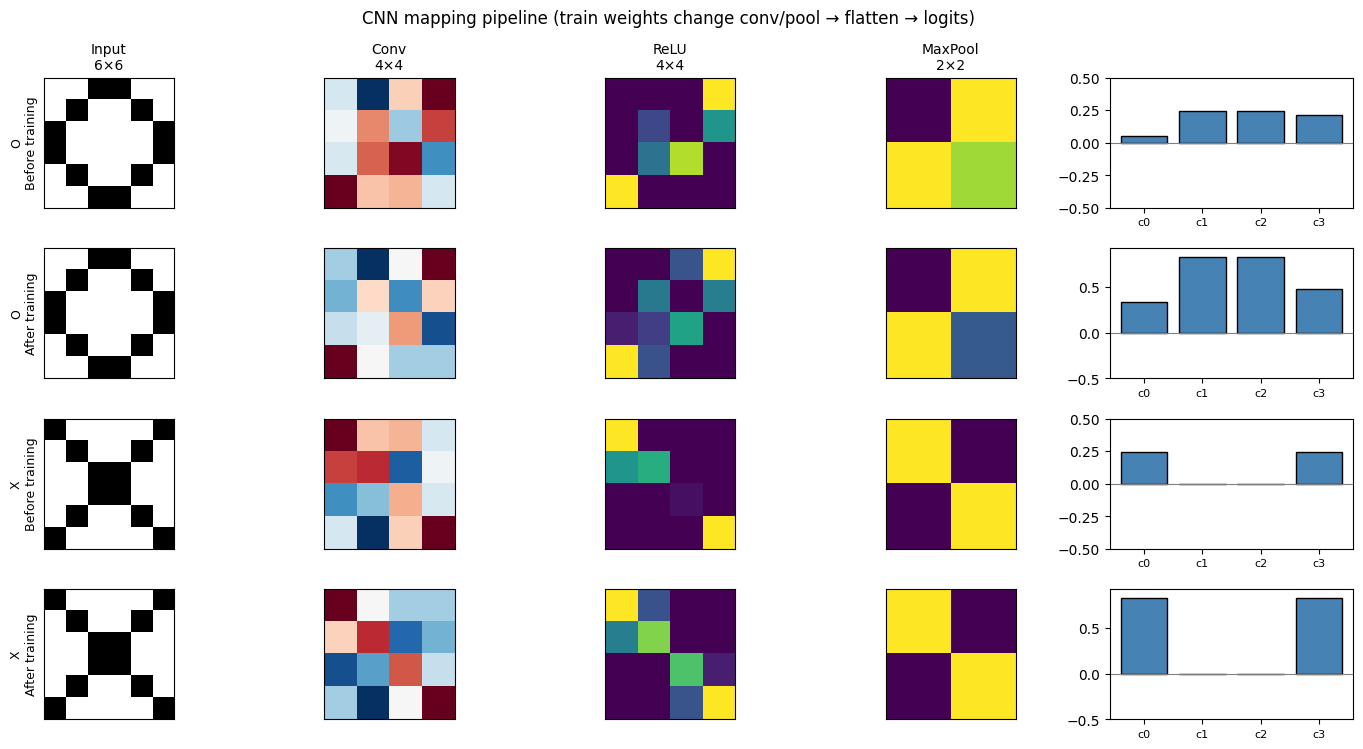

In [38]:
## Mapping after training — conv kernel + feature maps
conv_kernel_after = snapshot_conv_kernel(model)
fmaps_after = extract_feature_maps(model, input_images)
print_conv_kernel_summary(conv_kernel_before, conv_kernel_after)
visualize_conv_kernels(conv_kernel_before, conv_kernel_after)
print_mapping_summary(fmaps_after, title='After training')
visualize_mapping_pipeline(fmaps_before, fmaps_after)

In [39]:
for batch_num, (image, label) in enumerate(dataloader):
    
    ## First, run the image through the model to make a prediction
    prediction = model(image)
    
    ## Now make the prediction easy to read and interpret by
    ## running it through torch.softmax() and torch.round()
    predicted_label = torch.round(torch.softmax(prediction, dim=1), ## dim=0 applies softmax to rows, dim=1 applies soft to columns
                                  decimals=2) 
    
    ## Now print out the the predicted label and the original label
    ## so we see how well our CNN performed.
    print("predicted_label:", predicted_label)
    print("original label:", label)
    print("\n")

predicted_label: tensor([[0.3700, 0.6300]], grad_fn=<RoundBackward1>)
original label: tensor([[1., 0.]])


predicted_label: tensor([[0.1400, 0.8600]], grad_fn=<RoundBackward1>)
original label: tensor([[0., 1.]])




In [40]:
path_to_checkpoint = trainer.checkpoint_callback.best_model_path ## By default, "best" = "most recent"

In [41]:
## First, create a new Lightning Trainer
trainer = L.Trainer(max_epochs=700) # Before, max_epochs=100, so, by setting it to 700, we're adding 600 more.

## Then call trainer.fit() using the path to the most recent checkpoint files
## so that we can pick up where we left off.
trainer.fit(model, train_dataloaders=dataloader, ckpt_path=path_to_checkpoint)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Restoring states from the checkpoint path at e:\files\杂\qyx作业\MyDLClass\lightning_logs\version_26\checkpoints\epoch=99-step=200.ckpt
e:\files\杂\qyx作业\MyDLClass\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:566: The dirpath has changed from 'e:\\files\\杂\\qyx作业\\MyDLClass\\lightning_logs\\version_26\\checkpoints' to 'e:\\files\\杂\\qyx作业\\MyDLClass\\lightning_logs\\version_27\\checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_

Epoch 102: 100%|██████████| 2/2 [00:00<00:00, 120.92it/s, v_num=27]

Epoch 699: 100%|██████████| 2/2 [00:00<00:00, 168.38it/s, v_num=27]

`Trainer.fit` stopped: `max_epochs=700` reached.


Epoch 699: 100%|██████████| 2/2 [00:00<00:00, 95.65it/s, v_num=27] 


In [42]:
for batch_num, (image, label) in enumerate(dataloader):
    
    ## First, run the image through the model to make a prediction
    prediction = model(image)
    
    ## Now make the prediction easy to read and interpret by
    ## running it through torch.softmax() and torch.round()
    predicted_label = torch.round(torch.softmax(prediction, dim=1), ## dim=0 applies softmax to rows, dim=1 applies soft to columns
                                  decimals=2) 
    
    ## Now print out the the predicted label and the original label
    ## so we see how well our CNN performed.
    print("predicted_label:", predicted_label)
    print("original label:", label)
    print("\n")

predicted_label: tensor([[0.6700, 0.3300]], grad_fn=<RoundBackward1>)
original label: tensor([[1., 0.]])


predicted_label: tensor([[0.0100, 0.9900]], grad_fn=<RoundBackward1>)
original label: tensor([[0., 1.]])




In [43]:
shifted_x_image = [[0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 1, 0, 0, 0, 0]]
shifted_x_image

[[0, 1, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 1],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 1, 0, 0, 1],
 [0, 1, 0, 0, 0, 0]]

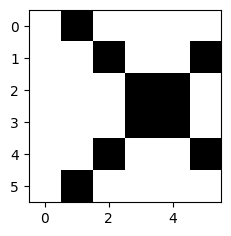

In [44]:
## When we only want to draw one image, we can omit 'nrows' and 'ncols' and 
## a single drawing element, ax, is returned.
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_x_image, cmap='gray_r') ## Setting cmap='gray_r' gives us reverse grayscale.

In [45]:
## First, let's make a prediction with the new image...
prediction = model(torch.tensor([shifted_x_image]).type(torch.float32))

## Now make the prediction easy to read and interpret by
## running it through torch.softmax() and torch.round()
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2) ## dim=0 applies argmax to rows, dim=1 applies argmax to colum

predicted_label

tensor([[0.1000, 0.9000]], grad_fn=<RoundBackward1>)

In [46]:
shifted_o_image = [[0, 1, 1, 0, 0, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 0, 0, 0, 1, 0],
                   [0, 0, 0, 0, 1, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 1, 1, 0, 0, 0]]
shifted_o_image

[[0, 1, 1, 0, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [0, 0, 0, 0, 1, 0],
 [0, 0, 0, 0, 1, 0],
 [1, 0, 0, 1, 0, 0],
 [0, 1, 1, 0, 0, 0]]

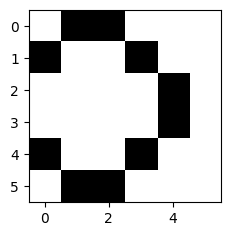

In [47]:
## When we only want to draw one image, we can omit 'nrows' and 'ncols' and 
## a single drawing element, ax, is returned.
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_o_image, cmap='gray_r') ## Setting cmap='gray_r' gives us reverse grayscale.

In [48]:
## Make a prediction with the new image...
prediction = model(torch.tensor([shifted_o_image]).type(torch.float32))

## Now make the prediction easy to read and interpret by
## running it through torch.softmax() and torch.round()
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2) ## dim=0 applies argmax to rows, dim=1 applies argmax to colum

predicted_label

tensor([[0.5900, 0.4100]], grad_fn=<RoundBackward1>)